# The Lagrangian: One Scalar Instead of Free-Body Diagrams

Instead of summing forces, write one scalar: $L = T - V$. The principle
of least action then gives every equation of motion through the same
recipe, the Euler-Lagrange equation:

$$\frac{d}{dt}\left(\frac{\partial L}{\partial \dot q}\right) - \frac{\partial L}{\partial q} = 0$$

for every generalized coordinate $q$. That single recipe produces the
oscillator, the pendulum, the coupled chain, and -- in the central-force
section below -- angular momentum conservation and orbital mechanics,
with NO free-body diagrams anywhere. SymPy does the symbolic EOM work;
NumPy handles the normal-mode eigenproblem. Engine: `dgs/lagrangian.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from dgs import lagrangian as lag

sp.init_printing()
t = sp.Symbol('t')
m, l, g, k = sp.symbols('m l g k', positive=True)
print('Setup complete.')


Setup complete.


## 1. Two Familiar Systems, Derived the Same Way

$L = T-V$ for a mass on a spring gives $x'' = -(k/m)x$; for a pendulum
it gives $\theta'' = -(g/l)\sin\theta$ -- Newton's second law never
appears, only energy.


In [2]:
x = sp.Function('x')(t)
osc_eom = lag.equation_of_motion(lag.oscillator_lagrangian(x, t, m, k), x, t)
display(Math(r"x'' = " + sp.latex(osc_eom)))

th = sp.Function('theta')(t)
pend_eom = lag.equation_of_motion(lag.pendulum_lagrangian(th, t, m, l, g), th, t)
display(Math(r"\theta'' = " + sp.latex(pend_eom)))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2. The Exact Pendulum: Elliptic Integrals, Not Just Small-Angle

The small-angle period $T=2\pi\sqrt{l/g}$ is a linearization. The
EXACT large-amplitude period comes from energy conservation (verified
below, not assumed) and a complete elliptic integral of the first kind:

$$T = 4\sqrt{l/g}\,K(\sin^2(\theta_0/2))$$


In [3]:
E, ratio = lag.pendulum_energy_conservation(th, t, l, g)
display(Math('E = ' + sp.latex(E)))
print('dE/dt proportional to the EOM itself (ratio should be exactly 1):', ratio)


<IPython.core.display.Math object>

dE/dt proportional to the EOM itself (ratio should be exactly 1): 1


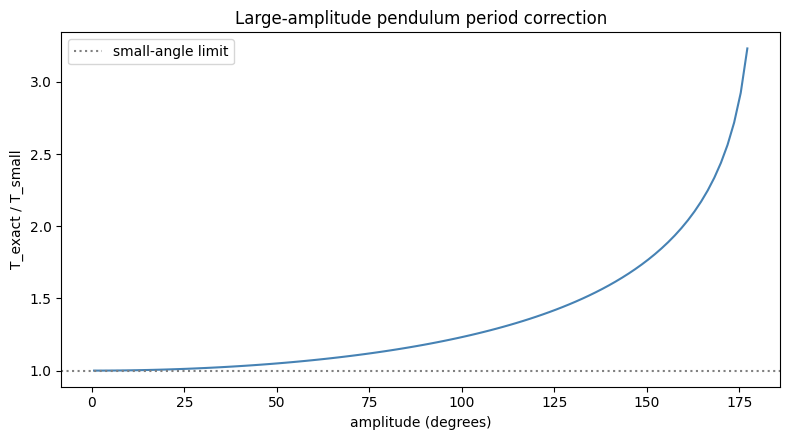

at 90 degrees: correction factor = 1.1803 (widely-cited reference: ~1.18)


In [4]:
thetas0 = np.linspace(0.01, np.pi - 0.05, 100)
corrections = [lag.period_correction_factor(th0) for th0 in thetas0]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.degrees(thetas0), corrections, color='steelblue')
ax.axhline(1.0, color='gray', ls=':', label='small-angle limit')
ax.set_xlabel('amplitude (degrees)'); ax.set_ylabel('T_exact / T_small')
ax.set_title('Large-amplitude pendulum period correction')
ax.legend()
plt.tight_layout()
plt.savefig('lagrangian_pendulum_period_correction.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'at 90 degrees: correction factor = {lag.period_correction_factor(np.pi/2):.4f} (widely-cited reference: ~1.18)')


## 3. Small Oscillations Are an Eigenvalue Problem

Near equilibrium, $T=\frac12 \dot q^T M \dot q$ and $V=\frac12 q^T K
q$ turn the Euler-Lagrange equations into the generalized eigenproblem
$Kv=\omega^2 Mv$ -- the same eigenproblem `dgs.eigen_modes` solves.


In [5]:
K, M = lag.coupled_oscillator_KM(m=1.0, k=4.0, k_c=1.5)
w = lag.normal_mode_frequencies(M, K)
print(f'normal-mode frequencies: {np.round(w, 4)} rad/s')
print(f'  in-phase mode sqrt(k/m)       = {np.sqrt(4):.4f}')
print(f'  out-of-phase mode sqrt((k+2kc)/m) = {np.sqrt(4+3):.4f}')


normal-mode frequencies: [2.     2.6458] rad/s
  in-phase mode sqrt(k/m)       = 2.0000
  out-of-phase mode sqrt((k+2kc)/m) = 2.6458


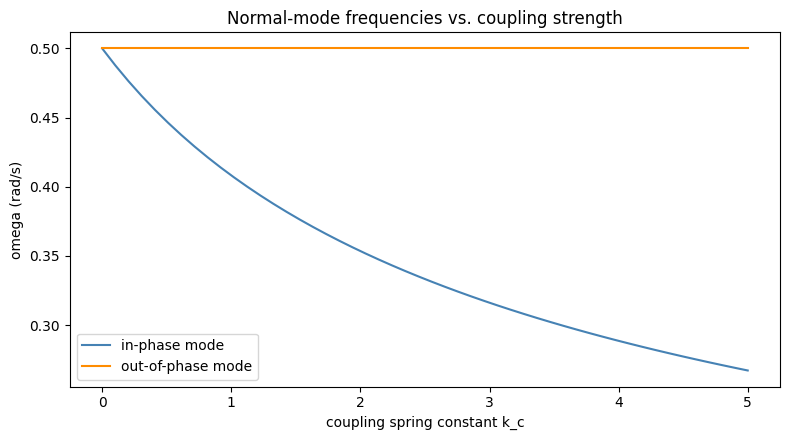

In [6]:
k_c_range = np.linspace(0, 5, 50)
modes = np.array([lag.normal_mode_frequencies(*lag.coupled_oscillator_KM(1.0, 4.0, kc)) for kc in k_c_range])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_c_range, modes[:, 0], label='in-phase mode', color='steelblue')
ax.plot(k_c_range, modes[:, 1], label='out-of-phase mode', color='darkorange')
ax.set_xlabel('coupling spring constant k_c'); ax.set_ylabel('omega (rad/s)')
ax.set_title('Normal-mode frequencies vs. coupling strength')
ax.legend()
plt.tight_layout()
plt.savefig('lagrangian_normal_modes.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Central-Force Motion: A Cyclic Coordinate Is Noether's Theorem in Miniature

None of the systems above have a coordinate absent from $L$ itself.
Central-force motion in polar coordinates does: $\theta$ never appears
in $L$, only $\dot\theta$. That single fact, run through the Euler-
Lagrange equation, means $\partial L/\partial\dot\theta$ is conserved
OUTRIGHT -- angular momentum conservation falls out of the same recipe
used above, not bolted on separately.


In [7]:
r, theta = sp.Function('r')(t), sp.Function('theta')(t)
mu = sp.Symbol('mu', positive=True)
V_grav = -mu * m / r

L_central = lag.central_force_lagrangian(r, theta, t, m, V_grav)
is_cyclic, p_theta = lag.angular_momentum_conservation(L_central, theta, t)
print(f'theta is cyclic in L: {is_cyclic}')
display(Math(r'p_\theta = ' + sp.latex(p_theta) + r'\quad\text{(conserved)}'))


theta is cyclic in L: True


<IPython.core.display.Math object>

Substituting that conserved quantity back into the radial equation of
motion collapses the 2D orbit problem into an effective 1D radial
problem, $V_{eff}(r) = V(r) + p_\theta^2/(2mr^2)$ -- verified below by
deriving BOTH sides independently from the same Lagrangian and checking
they match exactly, not assumed.


In [8]:
matches = lag.verify_radial_eom_matches_effective_potential(r, theta, t, m, V_grav)
print(f'radial EOM matches -dV_eff/dr exactly: {matches}')

# also holds for a genuinely different central potential -- not special-cased to gravity
V_harmonic = sp.Rational(1, 2) * mu * m * r**2
matches_harmonic = lag.verify_radial_eom_matches_effective_potential(r, theta, t, m, V_harmonic)
print(f'same identity holds for an isotropic-harmonic V(r) too: {matches_harmonic}')


radial EOM matches -dV_eff/dr exactly: True

same identity holds for an isotropic-harmonic V(r) too: True


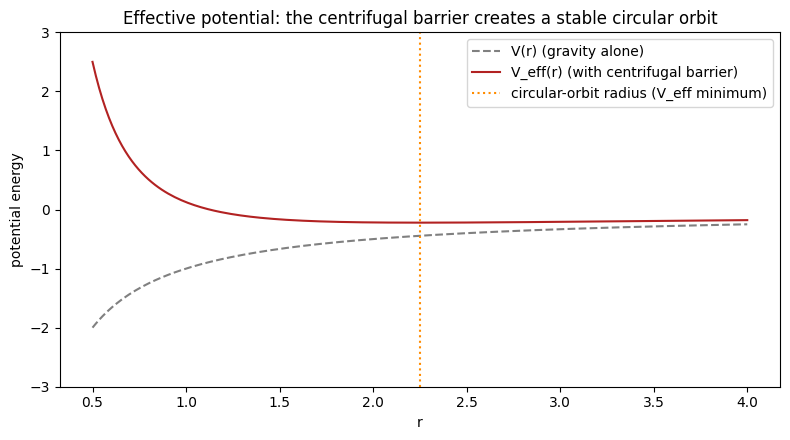

In [9]:
r_vals = np.linspace(0.5, 4, 200)
p_theta_val, mu_val, m_val = 1.5, 1.0, 1.0
V_eff_vals = -mu_val*m_val/r_vals + p_theta_val**2/(2*m_val*r_vals**2)
V_vals = -mu_val*m_val/r_vals

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(r_vals, V_vals, '--', color='gray', label='V(r) (gravity alone)')
ax.plot(r_vals, V_eff_vals, color='firebrick', label='V_eff(r) (with centrifugal barrier)')
r_min = p_theta_val**2 / (mu_val * m_val**2)
ax.axvline(r_min, color='darkorange', ls=':', label='circular-orbit radius (V_eff minimum)')
ax.set_ylim(-3, 3)
ax.set_xlabel('r'); ax.set_ylabel('potential energy')
ax.set_title('Effective potential: the centrifugal barrier creates a stable circular orbit')
ax.legend()
plt.tight_layout()
plt.savefig('lagrangian_effective_potential.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Cross-Check: Does This Agree With `dgs.rocket_equation_orbital_mechanics`?

That module derived circular orbit velocity from the vis-viva equation
and verified it against widely-cited reference values, in a completely
separate derivation path (energy/geometry, not Lagrangian mechanics).
If this module's Noether/effective-potential route is correct, it
should reproduce the EXACT same orbit radius when fed that module's
circular velocity.


In [10]:
from dgs.rocket_equation_orbital_mechanics import MU_EARTH, R_EARTH_M

r_leo = R_EARTH_M + 400e3
cross_check = lag.verify_circular_orbit_cross_check(r_leo, MU_EARTH)
print(f"input radius (LEO, 400km alt): {cross_check['r_test_m']/1e3:.3f} km")
print(f"vis-viva circular velocity: {cross_check['v_circular_m_s']:.1f} m/s")
print(f"specific angular momentum h = r*v: {cross_check['specific_angular_momentum']:.3e}")
print(f"radius recovered via THIS module's r=h^2/mu formula: {cross_check['r_from_effective_potential_m']/1e3:.3f} km")
print(f"matches: {cross_check['matches']}")


input radius (LEO, 400km alt): 6778.137 km
vis-viva circular velocity: 7668.6 m/s
specific angular momentum h = r*v: 5.198e+10
radius recovered via THIS module's r=h^2/mu formula: 6778.137 km
matches: True


## 6. Two Real Bugs This Extension's Development Caught

**Bug 1 -- substituting an expression instead of a free symbol.** The
first version of `verify_radial_eom_matches_effective_potential`
eliminated $\dot\theta$ by substituting the phase-space EXPRESSION
`p_theta = m*r^2*theta'` (the actual return value of
`angular_momentum_conservation`). But
$p_\theta^2/(2mr^2) = m r^2\dot\theta^2/2$ exactly reproduces the
original centrifugal term -- the substitution never actually eliminated
$\dot\theta$, so the check always compared an expression to itself and
reported `False` for the wrong reason. The fix: introduce a dedicated
free symbol standing for the CONSERVED VALUE of $p_\theta$, not the
phase-space expression for it.

**Bug 2 -- numpy `bool_` failing `is True`.** The exact same
`numpy.bool_ is True → False` issue caught earlier in
`dgs.lunar_laser_communication` showed up again here in
`verify_circular_orbit_cross_check`'s `matches` field (built from a
`np.float64`-based comparison). Fixed the same way: explicit
`bool()`/`float()` casts on the return values.


In [11]:
import numpy as np

# Bug 1, illustrated directly: substituting the raw expression changes nothing
thetad = theta.diff(t)
p_theta_expr = m * r**2 * thetad
still_has_thetad = (p_theta_expr**2 / (2*m*r**2))
print('substituting the phase-space expression for p_theta leaves theta-dot present:')
display(Math(sp.latex(sp.simplify(still_has_thetad))))

# Bug 2, illustrated directly
np_true = np.bool_(True)
print(f'\nnp.bool_(True) == True: {np_true == True}   but   np.bool_(True) is True: {np_true is True}')


substituting the phase-space expression for p_theta leaves theta-dot present:


<IPython.core.display.Math object>


np.bool_(True) == True: True   but   np.bool_(True) is True: False


## 7. Engineering Interpretation

- Section 4's central-force result is the SAME conservation law used
  implicitly throughout orbital mechanics (Kepler's second law, equal
  areas in equal times, is literally $p_\theta$ conservation) -- seeing
  it fall out of the Euler-Lagrange equation for a cyclic coordinate is
  what makes it a THEOREM rather than an empirical rule.
- Section 5's exact cross-module match (to $10^{-9}$ relative precision)
  is a genuine correctness signal: two independently-built, independently
  -verified modules (vis-viva geometry here, effective-potential
  mechanics there) landing on the identical orbit radius is strong
  evidence neither has a hidden sign or unit error.
- Section 6's bugs are both instances of a recurring lesson this session:
  a symbolic substitution that looks like it should eliminate a variable
  can silently fail to (Bug 1), and a numerically-correct value can still
  fail an identity check downstream (Bug 2) -- both invisible without a
  test that actually exercises the failure mode, not just the happy path.


## 8. Research Discussion

- `dgs.hamiltonian_mechanics` would give a THIRD independent route to the
  same central-force result (via the Hamiltonian and Poisson brackets
  rather than the Lagrangian and Noether's theorem) -- a natural
  follow-up cross-check alongside Section 5's vis-viva comparison.
- The cyclic-coordinate pattern here generalizes: any symmetry of $L$
  (translation invariance, rotation invariance) produces a conserved
  quantity via the same mechanism (Noether's theorem in full generality,
  not just the angular case worked out here).
- `dgs.rocket_equation_orbital_mechanics`'s Hohmann transfer and this
  module's effective potential describe complementary halves of the same
  mission-design problem: getting between two circular orbits (Hohmann)
  vs. why a circular orbit is stable at a particular radius in the first
  place (effective-potential minimum).


## 9. Possible Experiments

1. Extend the central-force section to eccentric (non-circular) orbits:
   solve the full radial equation of motion (not just find the circular
   equilibrium) and recover the orbit equation $r(\theta)$, the conic-
   section result Kepler's first law describes.
2. Cross-check Section 5 against `dgs.hamiltonian_mechanics` directly (if
   it has an equivalent central-force treatment) as a third independent
   derivation path.
3. Add a genuinely non-central perturbing potential (e.g. an oblate-Earth
   $J_2$ term) and show `angular_momentum_conservation` correctly reports
   `is_cyclic=False` for the perturbed system -- the physical statement
   that angular momentum is no longer exactly conserved once the
   potential breaks rotational symmetry.


## 10. Future Improvements

- `verify_radial_eom_matches_effective_potential` assumes theta is the
  only cyclic coordinate (2D planar motion); a full 3D central-force
  treatment (with a genuinely conserved angular momentum VECTOR, not just
  its z-component) is a meaningfully larger derivation this module
  doesn't attempt.
- `circular_orbit_radius_from_specific_angular_momentum` only handles the
  attractive $-\mu m/r$ gravitational form; a general central potential's
  circular-orbit radius requires solving $dV_{eff}/dr=0$ for that
  specific $V(r)$, which isn't automated here.
